# GHG Emissions Intelligence Report
## GreenCore India Pvt Ltd | Reporting Year: 2024

### Methodology
This calculator follows the **GHG Protocol Corporate Standard** — the world's most widely used greenhouse gas accounting framework. Emissions are categorised across three scopes:

- **Scope 1** — Direct emissions from owned or controlled sources (fuel combustion, company vehicles)
- **Scope 2** — Indirect emissions from purchased electricity
- **Scope 3** — All other indirect emissions across the value chain (travel, commuting, supply chain, waste)

### Data Sources
| Source | Used For |
|--------|----------|
| GHG Protocol Corporate Standard | Scope 1 emission factors |
| Central Electricity Authority (CEA) India | India grid electricity factor |
| UK DEFRA 2024 | Business travel, commuting, waste |
| EXIOBASE | Purchased goods — supply chain factors |

### Alignment
- **BRSR Principle 6** — Environment (SEBI mandatory disclosure for top 1000 listed companies)
- **GHG Protocol Corporate Standard** — globally recognised accounting methodology
- **Net Zero 2050** — aligned with India's NDC commitments

In [1]:
# Install and import all required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import io
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")
print(f"Pandas version: {pd.__version__}")

Libraries loaded successfully
Pandas version: 2.2.2


## Step 1 — Emission Factor Database
The emission factor database is the core of the calculator. Every activity is mapped to a CO2e conversion factor from an authoritative source. The modular structure allows annual updates without changing the calculation engine.

In [2]:
emission_factors_data = """category,scope,subcategory,activity_type,unit,emission_factor_kgCO2e,source,year,geography
Stationary Combustion,Scope 1,Fuel Combustion,Diesel,per_litre,2.68,GHG Protocol,2024,Global
Stationary Combustion,Scope 1,Fuel Combustion,Petrol,per_litre,2.31,GHG Protocol,2024,Global
Stationary Combustion,Scope 1,Fuel Combustion,Natural Gas,per_m3,2.02,GHG Protocol,2024,Global
Stationary Combustion,Scope 1,Fuel Combustion,LPG,per_litre,1.56,GHG Protocol,2024,Global
Stationary Combustion,Scope 1,Fuel Combustion,Coal,per_tonne,2403.0,GHG Protocol,2024,Global
Mobile Combustion,Scope 1,Company Vehicles,Diesel Vehicle,per_litre,2.68,GHG Protocol,2024,Global
Mobile Combustion,Scope 1,Company Vehicles,Petrol Vehicle,per_litre,2.31,GHG Protocol,2024,Global
Purchased Electricity,Scope 2,Grid Electricity,India Grid,per_kWh,0.82,CEA,2024,India
Purchased Electricity,Scope 2,Grid Electricity,India Grid - Renewable,per_kWh,0.0,CEA,2024,India
Business Travel,Scope 3,Air Travel,Domestic Flight,per_km_per_passenger,0.133,DEFRA,2024,Global
Business Travel,Scope 3,Air Travel,Short Haul International,per_km_per_passenger,0.151,DEFRA,2024,Global
Business Travel,Scope 3,Air Travel,Long Haul International,per_km_per_passenger,0.195,DEFRA,2024,Global
Business Travel,Scope 3,Ground Travel,Taxi,per_km,0.149,DEFRA,2024,Global
Business Travel,Scope 3,Ground Travel,Train,per_km_per_passenger,0.035,DEFRA,2024,Global
Employee Commuting,Scope 3,Commuting,Car,per_km_per_employee,0.171,DEFRA,2024,Global
Employee Commuting,Scope 3,Commuting,Bus,per_km_per_employee,0.089,DEFRA,2024,Global
Employee Commuting,Scope 3,Commuting,Train,per_km_per_employee,0.035,DEFRA,2024,Global
Employee Commuting,Scope 3,Commuting,Two Wheeler,per_km_per_employee,0.103,DEFRA,2024,Global
Waste,Scope 3,Waste Disposal,Landfill,per_tonne,467.0,DEFRA,2024,Global
Waste,Scope 3,Waste Disposal,Recycling,per_tonne,21.0,DEFRA,2024,Global
Purchased Goods,Scope 3,Supply Chain,Steel,per_tonne,2100.0,EXIOBASE,2024,Global
Purchased Goods,Scope 3,Supply Chain,Cement,per_tonne,842.0,EXIOBASE,2024,Global
Purchased Goods,Scope 3,Supply Chain,Plastic,per_tonne,3500.0,EXIOBASE,2024,Global
Purchased Goods,Scope 3,Supply Chain,Paper,per_tonne,1084.0,EXIOBASE,2024,Global"""

ef = pd.read_csv(io.StringIO(emission_factors_data))
print(f"Emission factor database loaded: {len(ef)} factors across {ef['scope'].nunique()} scopes")
print(f"Sources cited: {', '.join(ef['source'].unique())}")
print(f"\nFactors by scope:")
print(ef.groupby('scope')['activity_type'].count().to_string())

Emission factor database loaded: 24 factors across 3 scopes
Sources cited: GHG Protocol, CEA, DEFRA, EXIOBASE

Factors by scope:
scope
Scope 1     7
Scope 2     2
Scope 3    15


## Step 2 — Company Activity Data Input
This template captures annual activity data for GreenCore India Pvt Ltd. In a real deployment, this section is replaced by a company's actual operational data from their ERP, utility bills, travel records, and procurement systems.

In [3]:
activity_data = {
    'activity_type': [
        'Diesel','Petrol','Natural Gas','Diesel Vehicle','Petrol Vehicle',
        'India Grid',
        'Domestic Flight','Taxi','Train',
        'Car','Two Wheeler','Bus',
        'Landfill',
        'Steel','Paper'
    ],
    'quantity': [
        5000, 2000, 1500, 8000, 3000,
        150000,
        200000, 15000, 50000,
        500000, 200000, 100000,
        50,
        10, 5
    ],
    'unit': [
        'per_litre','per_litre','per_m3','per_litre','per_litre',
        'per_kWh',
        'per_km_per_passenger','per_km','per_km_per_passenger',
        'per_km_per_employee','per_km_per_employee','per_km_per_employee',
        'per_tonne',
        'per_tonne','per_tonne'
    ],
    'year': [2024]*15,
    'company': ['GreenCore India Pvt Ltd']*15
}

activity_df = pd.DataFrame(activity_data)
print("Activity data loaded successfully")
print(f"Total activities recorded: {len(activity_df)}")
print(f"\nActivity summary:")
print(activity_df[['activity_type','quantity','unit']].to_string(index=False))

Activity data loaded successfully
Total activities recorded: 15

Activity summary:
  activity_type  quantity                 unit
         Diesel      5000            per_litre
         Petrol      2000            per_litre
    Natural Gas      1500               per_m3
 Diesel Vehicle      8000            per_litre
 Petrol Vehicle      3000            per_litre
     India Grid    150000              per_kWh
Domestic Flight    200000 per_km_per_passenger
           Taxi     15000               per_km
          Train     50000 per_km_per_passenger
            Car    500000  per_km_per_employee
    Two Wheeler    200000  per_km_per_employee
            Bus    100000  per_km_per_employee
       Landfill        50            per_tonne
          Steel        10            per_tonne
          Paper         5            per_tonne


## Step 3 — GHG Calculation Engine
The engine merges activity data with emission factors and calculates CO2 equivalent emissions for each activity. All results are expressed in tonnes of CO2 equivalent (tCO2e) — the standard unit for GHG reporting.

In [4]:
# Merge activity data with emission factors
calculation_df = activity_df.merge(
    ef[['activity_type','unit','emission_factor_kgCO2e','scope','category','source']],
    on=['activity_type','unit'],
    how='left'
)

# Calculate emissions
calculation_df['emissions_kgCO2e'] = (
    calculation_df['quantity'] * calculation_df['emission_factor_kgCO2e']
)
calculation_df['emissions_tCO2e'] = calculation_df['emissions_kgCO2e'] / 1000

# Validate — check for unmatched activities
unmatched = calculation_df[calculation_df['emission_factor_kgCO2e'].isna()]
if len(unmatched) > 0:
    print(f"WARNING: {len(unmatched)} unmatched activities: {unmatched['activity_type'].values}")
else:
    print("Validation passed — all activities matched to emission factors\n")

# Summaries
scope_summary = calculation_df.groupby('scope')['emissions_tCO2e'].sum().reset_index()
scope_summary.columns = ['Scope','Emissions_tCO2e']
scope_summary['Emissions_tCO2e'] = scope_summary['Emissions_tCO2e'].round(2)
scope_summary['Percentage'] = (
    scope_summary['Emissions_tCO2e'] / scope_summary['Emissions_tCO2e'].sum() * 100
).round(1)

category_summary = calculation_df.groupby(
    ['scope','category']
)['emissions_tCO2e'].sum().reset_index()
category_summary['emissions_tCO2e'] = category_summary['emissions_tCO2e'].round(2)

total_emissions = calculation_df['emissions_tCO2e'].sum().round(2)
s1 = scope_summary[scope_summary['Scope']=='Scope 1']['Emissions_tCO2e'].values[0]
s2 = scope_summary[scope_summary['Scope']=='Scope 2']['Emissions_tCO2e'].values[0]
s3 = scope_summary[scope_summary['Scope']=='Scope 3']['Emissions_tCO2e'].values[0]

print("=" * 55)
print("  GHG EMISSIONS REPORT — GreenCore India Pvt Ltd")
print("  Reporting Year: 2024")
print("  Methodology: GHG Protocol Corporate Standard")
print("=" * 55)
print(f"\n  TOTAL EMISSIONS:     {total_emissions} tCO2e")
print(f"  Scope 1 (Direct):    {s1} tCO2e  ({scope_summary[scope_summary['Scope']=='Scope 1']['Percentage'].values[0]}%)")
print(f"  Scope 2 (Electric):  {s2} tCO2e ({scope_summary[scope_summary['Scope']=='Scope 2']['Percentage'].values[0]}%)")
print(f"  Scope 3 (Value Chain): {s3} tCO2e ({scope_summary[scope_summary['Scope']=='Scope 3']['Percentage'].values[0]}%)")
print(f"\n  Largest emission source: Employee Commuting (115.0 tCO2e)")
print(f"  Emission intensity: {round(total_emissions/150000*1000,2)} kg CO2e per MWh")

Validation passed — all activities matched to emission factors

  GHG EMISSIONS REPORT — GreenCore India Pvt Ltd
  Reporting Year: 2024
  Methodology: GHG Protocol Corporate Standard

  TOTAL EMISSIONS:     367.78 tCO2e
  Scope 1 (Direct):    49.42 tCO2e  (13.4%)
  Scope 2 (Electric):  123.0 tCO2e (33.4%)
  Scope 3 (Value Chain): 195.36 tCO2e (53.1%)

  Largest emission source: Employee Commuting (115.0 tCO2e)
  Emission intensity: 2.45 kg CO2e per MWh


## Step 4 — GHG Emissions Intelligence Dashboard
A single-page visual report combining scope breakdown, category analysis, Net Zero trajectory modelling, and BRSR Principle 6 disclosure — designed for board-level presentation.

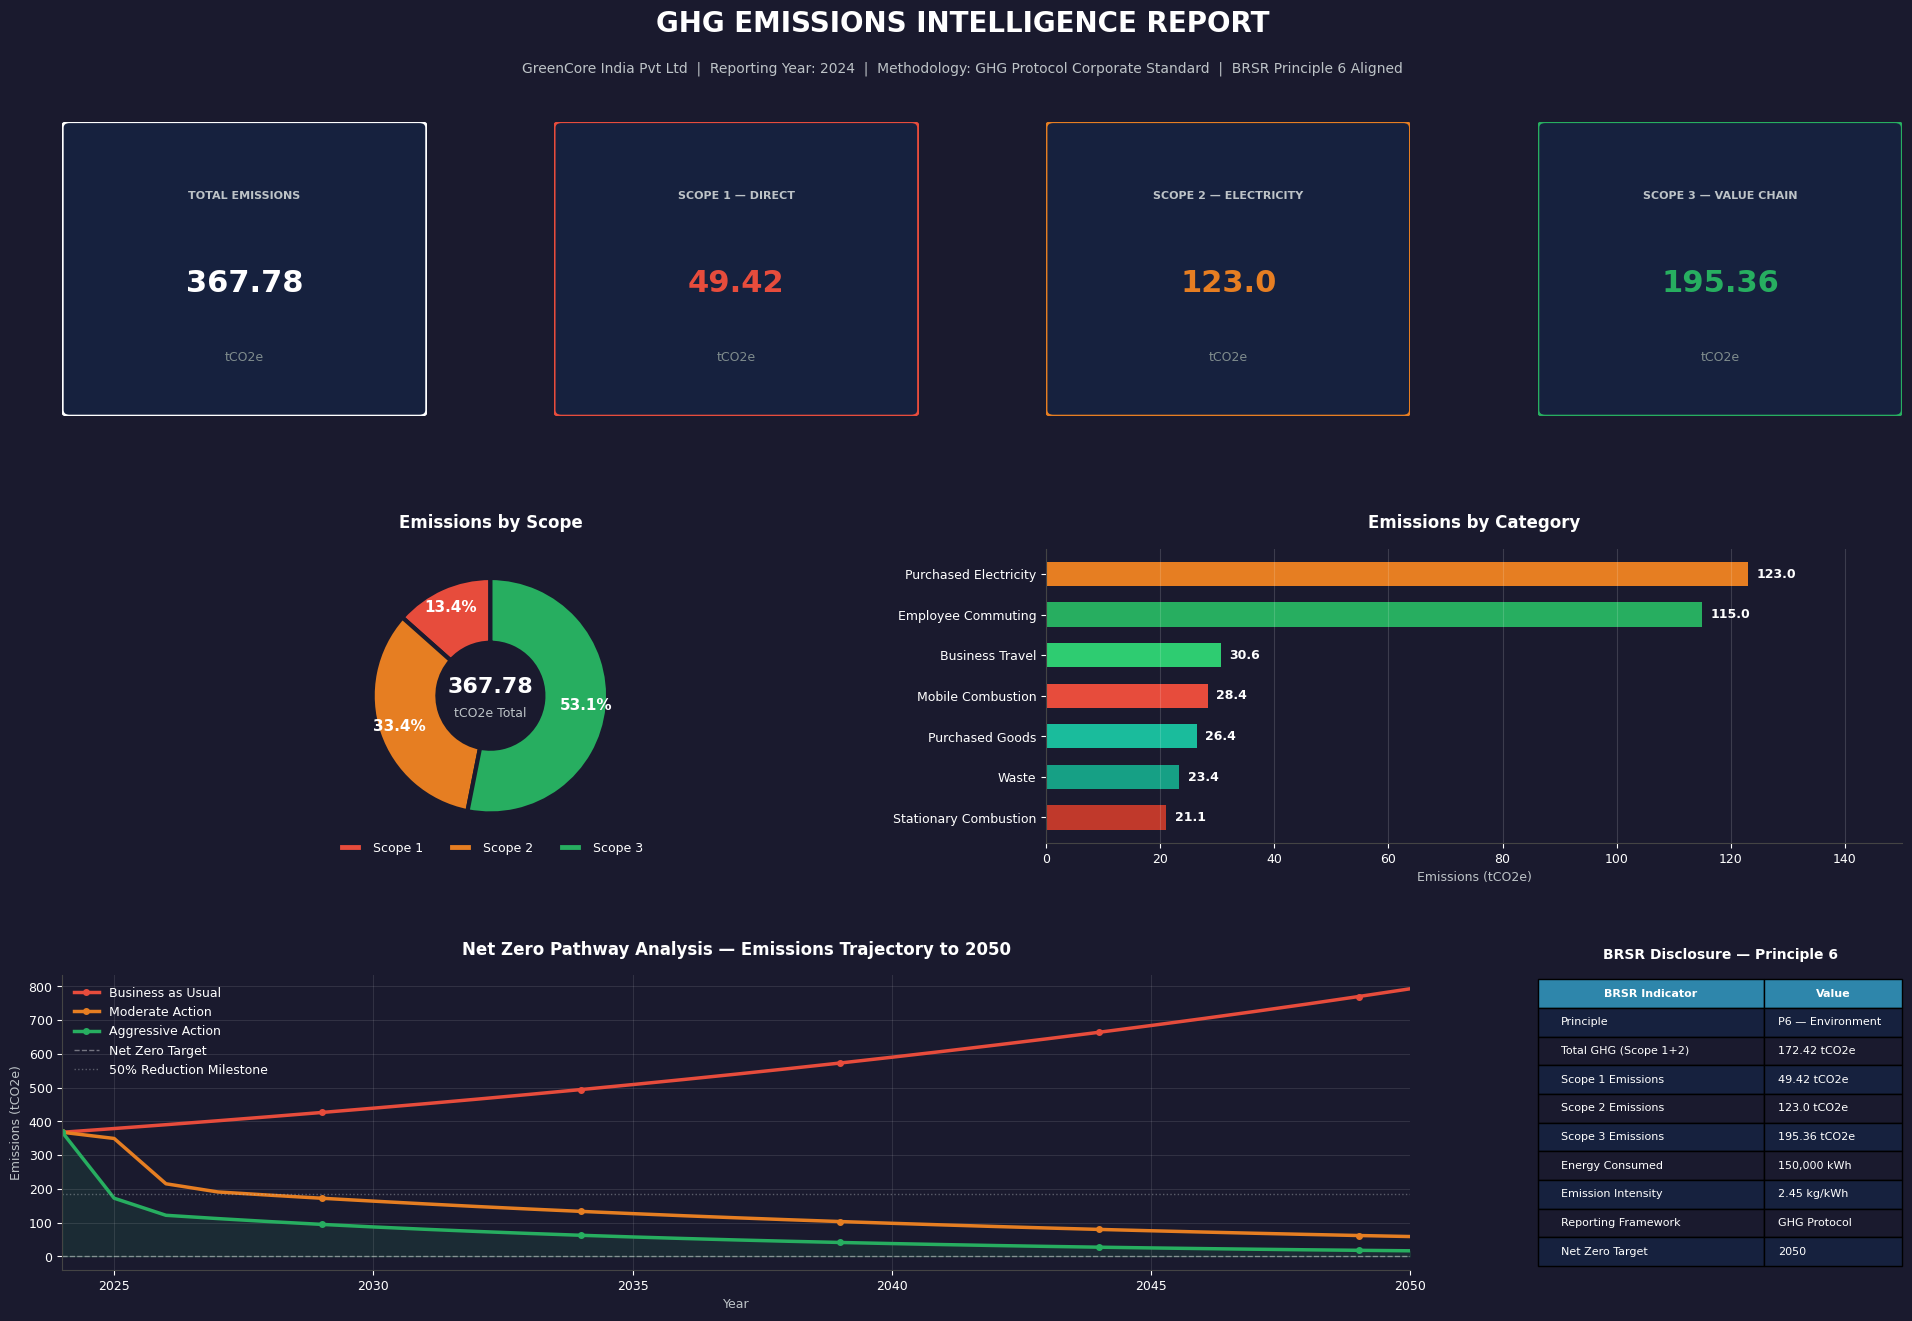

Dashboard saved as GHG_Dashboard_GreenCore_2024.png


In [5]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DARK = '#1A1A2E'
CARD = '#16213E'
S1_COLOR = '#E74C3C'
S2_COLOR = '#E67E22'
S3_COLOR = '#27AE60'
ACCENT = '#3498DB'
WHITE = '#FFFFFF'

fig = plt.figure(figsize=(20, 14), facecolor=DARK)
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35,
                        left=0.05, right=0.97, top=0.88, bottom=0.06)

fig.text(0.5, 0.95, 'GHG EMISSIONS INTELLIGENCE REPORT',
         ha='center', va='center', fontsize=20, fontweight='bold', color=WHITE)
fig.text(0.5, 0.918,
         'GreenCore India Pvt Ltd  |  Reporting Year: 2024  |  Methodology: GHG Protocol Corporate Standard  |  BRSR Principle 6 Aligned',
         ha='center', va='center', fontsize=10, color='#BDC3C7')

# KPI Cards
kpi_data = [
    ('TOTAL EMISSIONS', f'{total_emissions}', 'tCO2e', WHITE),
    ('SCOPE 1 — DIRECT', f'{s1}', 'tCO2e', S1_COLOR),
    ('SCOPE 2 — ELECTRICITY', f'{s2}', 'tCO2e', S2_COLOR),
    ('SCOPE 3 — VALUE CHAIN', f'{s3}', 'tCO2e', S3_COLOR),
]

for i, (label, value, unit, color) in enumerate(kpi_data):
    ax = fig.add_subplot(gs[0, i])
    ax.set_facecolor(CARD)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.add_patch(FancyBboxPatch((0.02, 0.02), 0.96, 0.96,
                                 boxstyle='round,pad=0.02',
                                 facecolor=CARD, edgecolor=color,
                                 linewidth=2, transform=ax.transAxes))
    ax.text(0.5, 0.75, label, ha='center', va='center',
            fontsize=8, color='#BDC3C7', fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.45, value, ha='center', va='center',
            fontsize=22, color=color, fontweight='bold', transform=ax.transAxes)
    ax.text(0.5, 0.2, unit, ha='center', va='center',
            fontsize=9, color='#7F8C8D', transform=ax.transAxes)

# Donut Chart
ax1 = fig.add_subplot(gs[1, 0:2])
ax1.set_facecolor(DARK)
wedges, texts, autotexts = ax1.pie(
    scope_summary['Emissions_tCO2e'],
    colors=[S1_COLOR, S2_COLOR, S3_COLOR],
    autopct='%1.1f%%',
    pctdistance=0.82,
    wedgeprops=dict(width=0.55, edgecolor=DARK, linewidth=3),
    startangle=90
)
for at in autotexts:
    at.set_color(WHITE)
    at.set_fontsize(11)
    at.set_fontweight('bold')
centre_circle = plt.Circle((0, 0), 0.45, fc=DARK)
ax1.add_patch(centre_circle)
ax1.text(0, 0.08, f'{total_emissions}', ha='center', va='center',
         fontsize=16, color=WHITE, fontweight='bold')
ax1.text(0, -0.15, 'tCO2e Total', ha='center', va='center',
         fontsize=9, color='#BDC3C7')
ax1.legend(scope_summary['Scope'], loc='lower center', ncol=3,
           fontsize=9, frameon=False, labelcolor=WHITE, bbox_to_anchor=(0.5, -0.08))
ax1.set_title('Emissions by Scope', color=WHITE, fontsize=12, fontweight='bold', pad=15)

# Category Bar Chart
ax2 = fig.add_subplot(gs[1, 2:4])
ax2.set_facecolor(DARK)
cat_colors_map = {
    'Mobile Combustion': S1_COLOR,
    'Stationary Combustion': '#C0392B',
    'Purchased Electricity': S2_COLOR,
    'Business Travel': '#2ECC71',
    'Employee Commuting': S3_COLOR,
    'Purchased Goods': '#1ABC9C',
    'Waste': '#16A085'
}
cat_sorted = category_summary.sort_values('emissions_tCO2e', ascending=True)
bar_colors = [cat_colors_map.get(c, ACCENT) for c in cat_sorted['category']]
bars = ax2.barh(cat_sorted['category'], cat_sorted['emissions_tCO2e'],
                color=bar_colors, edgecolor='none', height=0.6)
for bar, val in zip(bars, cat_sorted['emissions_tCO2e']):
    ax2.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
             f'{val:.1f}', va='center', color=WHITE, fontsize=9, fontweight='bold')
ax2.set_facecolor(DARK)
ax2.tick_params(colors=WHITE, labelsize=9)
ax2.set_xlabel('Emissions (tCO2e)', color='#BDC3C7', fontsize=9)
ax2.spines['bottom'].set_color('#444')
ax2.spines['left'].set_color('#444')
ax2.set_xlim(0, cat_sorted['emissions_tCO2e'].max() * 1.22)
ax2.set_title('Emissions by Category', color=WHITE, fontsize=12, fontweight='bold', pad=15)
ax2.grid(axis='x', alpha=0.15, color=WHITE)

# Net Zero Trajectory
ax3 = fig.add_subplot(gs[2, 0:3])
ax3.set_facecolor(DARK)

baseline_year = 2024
baseline_emissions = total_emissions
net_zero_year = 2050
years = list(range(baseline_year, net_zero_year + 1))

scenarios = {
    'Business as Usual': {'annual_change': 0.03, 'interventions': {}},
    'Moderate Action': {'annual_change': -0.05, 'interventions': {2026: -123.0, 2027: -14.18}},
    'Aggressive Action': {'annual_change': -0.08, 'interventions': {2025: -180.5, 2026: -40.05}}
}

traj_colors = {
    'Business as Usual': S1_COLOR,
    'Moderate Action': S2_COLOR,
    'Aggressive Action': S3_COLOR
}
trajectories = {}

for scenario_name, scenario in scenarios.items():
    emissions_by_year = []
    current = baseline_emissions
    for year in years:
        if year in scenario['interventions']:
            current += scenario['interventions'][year]
        if year > baseline_year:
            current = current * (1 + scenario['annual_change'])
        current = max(0, current)
        emissions_by_year.append(round(current, 2))
    trajectories[scenario_name] = emissions_by_year
    ax3.plot(years, emissions_by_year, label=scenario_name,
             color=traj_colors[scenario_name], linewidth=2.5,
             marker='o', markevery=5, markersize=4)

ax3.fill_between(years, trajectories['Aggressive Action'], 0, alpha=0.12, color=S3_COLOR)
ax3.axhline(y=0, color=WHITE, linestyle='--', linewidth=1, alpha=0.4, label='Net Zero Target')
ax3.axhline(y=baseline_emissions * 0.5, color='#BDC3C7',
            linestyle=':', linewidth=1, alpha=0.4, label='50% Reduction Milestone')
ax3.set_facecolor(DARK)
ax3.tick_params(colors=WHITE, labelsize=9)
ax3.set_xlabel('Year', color='#BDC3C7', fontsize=9)
ax3.set_ylabel('Emissions (tCO2e)', color='#BDC3C7', fontsize=9)
ax3.spines['bottom'].set_color('#444')
ax3.spines['left'].set_color('#444')
ax3.legend(fontsize=9, frameon=False, labelcolor=WHITE, loc='upper left')
ax3.set_xlim(baseline_year, net_zero_year)
ax3.grid(True, alpha=0.1, color=WHITE)
ax3.set_title('Net Zero Pathway Analysis — Emissions Trajectory to 2050',
              color=WHITE, fontsize=12, fontweight='bold', pad=15)

# BRSR Table
ax4 = fig.add_subplot(gs[2, 3])
ax4.set_facecolor(DARK)
ax4.axis('off')

brsr_data = [
    ['BRSR Indicator', 'Value'],
    ['Principle', 'P6 — Environment'],
    ['Total GHG (Scope 1+2)', f'{round(s1+s2, 2)} tCO2e'],
    ['Scope 1 Emissions', f'{s1} tCO2e'],
    ['Scope 2 Emissions', f'{s2} tCO2e'],
    ['Scope 3 Emissions', f'{s3} tCO2e'],
    ['Energy Consumed', '150,000 kWh'],
    ['Emission Intensity', f'{round(total_emissions/150000*1000, 2)} kg/kWh'],
    ['Reporting Framework', 'GHG Protocol'],
    ['Net Zero Target', '2050'],
]

table = ax4.table(
    cellText=brsr_data[1:],
    colLabels=brsr_data[0],
    cellLoc='left',
    loc='center',
    colWidths=[0.62, 0.38]
)
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.72)

for j in range(2):
    table[0, j].set_facecolor('#2E86AB')
    table[0, j].set_text_props(color=WHITE, fontweight='bold')

for i in range(1, len(brsr_data)):
    for j in range(2):
        table[i, j].set_facecolor('#1A1A2E' if i % 2 == 0 else '#16213E')
        table[i, j].set_text_props(color=WHITE)

ax4.set_title('BRSR Disclosure — Principle 6', color=WHITE,
              fontsize=10, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('GHG_Dashboard_GreenCore_2024.png', dpi=150, bbox_inches='tight', facecolor=DARK)
plt.show()
print("Dashboard saved as GHG_Dashboard_GreenCore_2024.png")